In [1]:
# import pandas as pd
# import pickle
# import torch
# from torch.utils.data import DataLoader, Subset
# import os
# import numpy as np
# import sys
# # Aggiunge la cartella src al path
# sys.path.append(os.path.abspath('../MAIN PHASE/src'))
# # Ora puoi importare normalmente
# from data_class import Nuc_Dataset
# #from utils import training_and_validation_loop_classification, collate_fn,test_classification,training_validation_and_test_loop_classification,find_best_threshold
# from utils import test_classification,training_validation_and_test_loop_classification


# from model import CadmusDNA,TransformerNuc_Cadmus
# from collections import Counter

# from sklearn.model_selection import StratifiedKFold, train_test_split
# import math
# import seaborn as sns
# import matplotlib.pyplot as plt
# from collections import defaultdict
# from Bio.Seq import Seq
# import random

# import pandas as pd
# import os
# import sys
# # Aggiunge la cartella src al path
# sys.path.append(os.path.abspath('../src'))
# from transformers import AutoTokenizer, AutoModel
# import torch
# import pandas as pd


In [2]:
import os
import sys
import math
import random
import pickle
from collections import Counter, defaultdict

# --- Third Party Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.Seq import Seq

# --- Machine Learning & Deep Learning ---
import torch
from torch.utils.data import DataLoader, Subset
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import StratifiedKFold, train_test_split

# --- Local Imports (Setup Path) ---
# Assicurati che il percorso punti alla cartella corretta (ho tenuto '../src' come standard)
sys.path.append(os.path.abspath('../MAIN PHASE/src'))

from data_class import Nuc_Dataset
from utils import test_classification, training_validation_and_test_loop_classification
from model import CadmusDNA, TransformerNuc_Cadmus

In [3]:
import pandas as pd
d = pd.read_pickle('../MAIN PHASE/data/data_pkl/Lymphoblastoid_99_8_percentile.pkl')[0:2]

In [4]:
for d1, d2 in zip(d, d):
    d1['sequence_rev'] = str(Seq(d1['sequence']).reverse_complement())

In [5]:
d

[{'sequence': 'GATGAGTAGAATCCCCCAGAAAGGAGGAGGGTGTTTCTGGCACAGGACATGAACAAGGACACTGAGGCCCAGGGTGAGAAGCAGGGAGACGAGCAGGGAAGCTGGGGCGACCATAGGACAGAGGAAGGGCCTGCACCCCCGCCTGCCACGCCAAGGAGTGTAGTCCTCATGGCAGAAGTGGGGAGCCACGGAAGCTCTTTG',
  'label': 1,
  'embedding': 0,
  'sequence_rev': 'CAAAGAGCTTCCGTGGCTCCCCACTTCTGCCATGAGGACTACACTCCTTGGCGTGGCAGGCGGGGGTGCAGGCCCTTCCTCTGTCCTATGGTCGCCCCAGCTTCCCTGCTCGTCTCCCTGCTTCTCACCCTGGGCCTCAGTGTCCTTGTTCATGTCCTGTGCCAGAAACACCCTCCTCCTTTCTGGGGGATTCTACTCATC'},
 {'sequence': 'AAGCCATTGTATGTGTGGCTGGTGGGGTGGGGGCACACACCTGCACCTGCTATCCAGAAACCCCAGACTGATGGATTTTTATTTTGGAAGCATTGCATCAACCAGGAGAGAAGACCACTTGGGGGAGTGGGACCCTGAGCCGAGGTGATCCTTGGCCATGAGAGGTGAGACCCACTTTCTTAAAGAAGAGATGAGCGGGAG',
  'label': 1,
  'embedding': 0,
  'sequence_rev': 'CTCCCGCTCATCTCTTCTTTAAGAAAGTGGGTCTCACCTCTCATGGCCAAGGATCACCTCGGCTCAGGGTCCCACTCCCCCAAGTGGTCTTCTCTCCTGGTTGATGCAATGCTTCCAAAATAAAAATCCATCAGTCTGGGGTTTCTGGATAGCAGGTGCAGGTGTGTGCCCCCACCCCACCAGCCACACATACAATGGCTT'}]

In [6]:
def set_seed(seed=42):
    random.seed(seed)                          # Seed Python (modulo random)
    np.random.seed(seed)                       # Seed NumPy
    torch.manual_seed(seed)                    # Seed PyTorch CPU
    torch.cuda.manual_seed(seed)               # Seed PyTorch CUDA (una GPU)
    torch.cuda.manual_seed_all(seed)           # Seed PyTorch CUDA (tutte le GPU)

    torch.backends.cudnn.deterministic = True  # Usa algoritmi deterministici
    torch.backends.cudnn.benchmark = False     # Disabilita ottimizzazioni non deterministiche

    print(f"Seeds fixed with seed = {seed}")
set_seed()

Seeds fixed with seed = 42


In [7]:
#conto le occorrenze per ogni classe
labels = [entry['label'] for entry in d]


In [8]:
best_hyperparameters = {'dropout_rate': 0.3143462158665756,
 'num_heads': 8,
 'batch_size': 32,
 'lr': 1.4271180164633878e-06,
 'weight_decay': 1.2306663346888495e-06,
 'patience': 12}

In [9]:

# #CV WITH EARLY STOPPING

from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef, roc_auc_score
import numpy as np

def classification_metrics(y_true, probs_pred, threshold=0.5):
    """
    Calcola Sensitivity, Specificity, Accuracy, MCC e AUC
    a partire da y_true (etichette vere) e probs_pred (probabilità predette).
    
    Parametri:
        y_true: array-like di etichette vere (0 o 1)
        probs_pred: array-like di probabilità predette (float tra 0 e 1)
        threshold: soglia di classificazione (default 0.5)
    
    Ritorna:
        dizionario con le metriche richieste
    """
    # Conversione in predizioni binarie
    y_pred = (np.array(probs_pred) >= threshold).astype(int)
    y_true = np.array(y_true)
    
    # Matrice di confusione
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Metriche
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    auc = roc_auc_score(y_true, probs_pred)
    
    return {
        "Sensitivity_val": sensitivity,
        "Specificity_val": specificity,
        "Accuracy_val": accuracy,
        "MCC_val": mcc,
        "AUC_val": auc
    }

    

g = torch.Generator()
g.manual_seed(0) # Usa lo stesso seed

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dim_embedding = 2560#1280#2560
# data = [x for x in data if x['embedding'].shape[0] == 37]#[:3000] 


dataset = Nuc_Dataset(d, dim_embedding, drop_last=False)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False, worker_init_fn=seed_worker, generator=g, drop_last=False )


# dataset_train = Nuc_Dataset(dataset_sapiens_lymphoblastoid, dim_embedding, drop_last=False)
# dataset_test_act = Nuc_Dataset(dataset_sapiens_cd4t_act, dim_embedding, drop_last=False)
# dataset_test_rest = Nuc_Dataset(dataset_sapiens_cd4t_rest, dim_embedding, drop_last=False)

# dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, worker_init_fn=seed_worker, generator=g, drop_last=False )
# dataloader_test_act = DataLoader(dataset_test_act, batch_size=32, shuffle=False, worker_init_fn=seed_worker, generator=g, drop_last=False )
# dataloader_test_rest = DataLoader(dataset_test_rest, batch_size=32, shuffle=False, worker_init_fn=seed_worker, generator=g, drop_last=False )

transf_parameters_att = {'input_dim': dim_embedding, 
                         'dropout_rate': best_hyperparameters['dropout_rate'], 
                         'num_heads': best_hyperparameters['num_heads']}   



In [10]:
# === RICARICA ===
best_model = CadmusDNA(TransformerNuc_Cadmus, transf_parameters_att, device)
state_dict = torch.load("../../Nucleosome_work/notebooks/best_model_weights_99_8_percentile_fold4.pt", map_location=device)
best_model.load_state_dict(state_dict)
best_model.to(device)
best_model.eval()



Using device: cuda


2026-02-05 16:48:21.190421: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-05 16:48:21.212964: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-05 16:48:21.212992: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-05 16:48:21.213886: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-05 16:48:21.218180: I tensorflow/core/platform/cpu_feature_guar

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of EsmModel were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-2.5B-multi-species and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


CadmusDNA(
  (model_LLM): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(4105, 2560, padding_idx=1)
      (dropout): Dropout(p=0.0, inplace=False)
      (position_embeddings): Embedding(1002, 2560, padding_idx=1)
    )
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-31): 32 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=2560, out_features=2560, bias=True)
              (key): Linear(in_features=2560, out_features=2560, bias=True)
              (value): Linear(in_features=2560, out_features=2560, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=2560, out_features=2560, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (LayerNorm): LayerNorm((2560,), eps=1e-12, elementwise_affine=True)
          )
          (in

In [11]:

def invert_attention(A):
    """
    Inverte le posizioni da 1 in poi nella matrice di attenzione A,
    lasciando la posizione 0 ([CLS]) invariata.
    
    A: matrice di attenzione (L, L)
    """
    L = A.shape[0]
    assert A.shape[0] == A.shape[1], "La matrice deve essere quadrata"
    
    # Costruisci un nuovo ordine di indici: [0, L-1, L-2, ..., 1]
    perm = [0] + list(range(L-1, 0, -1))
    
    # Applica la permutazione a righe e colonne
    A_corrected = A[np.ix_(perm, perm)]
    
    return A_corrected



In [12]:
import os
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm






import os
import gc
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
import os
import gc
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

def output_model_batch_inference(batch, model, device, rc=True):
    """
    Versione per inferenza End-to-End.
    Passa le STRINGHE (DNA) grezze al modello, che si occuperà internamente
    di calcolare l'embedding e spostarlo su GPU.
    """
    
    # 1. Estrazione delle sequenze grezze (Stringhe)
    inputs = list(batch['sequence'])
    
    # 2. Gestione Reverse Complement (RC)
    if rc:
        if 'sequence_rev' in batch:
            inputs_rc = list(batch['sequence_rev'])
        else:
            # Fallback: usa forward se manca RC
            inputs_rc = inputs
    else:
        inputs_rc = inputs

    # 3. Passaggio al Modello
    output, importance = model(inputs)
    output_rc, importance_rc = model(inputs_rc)

    return output, output_rc, importance, importance_rc


def predict_only(model, dataloader, threshold=0.5, return_importance=True):
    """
    Esegue l'inferenza e restituisce predizioni, probabilità e, se richiesto, 
    le matrici di importanza per Forward e Reverse Complement.
    """
    # Assicura che il modello sia sul device corretto e in eval mode
    device = next(model.parameters()).device
    model.eval()
    
    all_probs = []
    all_importance = []
    all_importance_rc = [] # Lista per l'importanza RC
    
    print(f"Avvio inferenza su device: {device} (Calcolo embeddings real-time)")
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Predicting"):
            
            # Chiama la funzione corretta che passa le stringhe
            output, output_rc, imp, imp_rc = output_model_batch_inference(batch, model, device, rc=True)
            
            # Calcolo Probabilità
            probs = torch.sigmoid((output + output_rc) / 2)
            
            # Salvataggio Probabilità (CPU)
            all_probs.extend(probs.cpu().numpy().flatten().tolist())
            
            # Salvataggio Importanza (se richiesto)
            if return_importance:
                all_importance.append(imp.cpu().numpy())
                all_importance_rc.append(imp_rc.cpu().numpy())

            # Pulizia memoria GPU
            del output, output_rc, probs, imp, imp_rc

    # Output finale
    probs_np = np.array(all_probs)
    preds_np = (probs_np >= threshold).astype(int)
    
    result = {
        'probabilities': probs_np,
        'predictions': preds_np
    }
    
    if return_importance:
        # Concatena le liste di batch in un unico array (se possibile) o lascia come lista di array
        # Nota: Se le dimensioni variano tra batch, meglio lasciare liste. 
        # Se fisse, puoi usare np.vstack o np.concatenate.
        result['importance'] = all_importance
        result['importance_rc'] = all_importance_rc
        
    return result
# 2. Seleziona dati di test
dataset_to_study = d#random.sample(dataset_sapiens_cd4t_act, k= 5000)#dataset_sapiens_lymphoblastoid#[dataset[i] for i in val_idx]  # Assicurati che gli indici siano corretti

# 3. Crea dataloader
#test = Nuc_Dataset(dataset_to_study, dim_embedding)
test = DataLoader(dataset_to_study, batch_size=64, shuffle=False)

# 4. Inference
results = predict_only(best_model, test)

Avvio inferenza su device: cuda:0 (Calcolo embeddings real-time)


Predicting: 100%|█████████████████████████████████| 1/1 [00:00<00:00,  5.90it/s]


/tmp/ipykernel_137466/695129097.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_plot, x='Token', y='Attention', palette=colors)


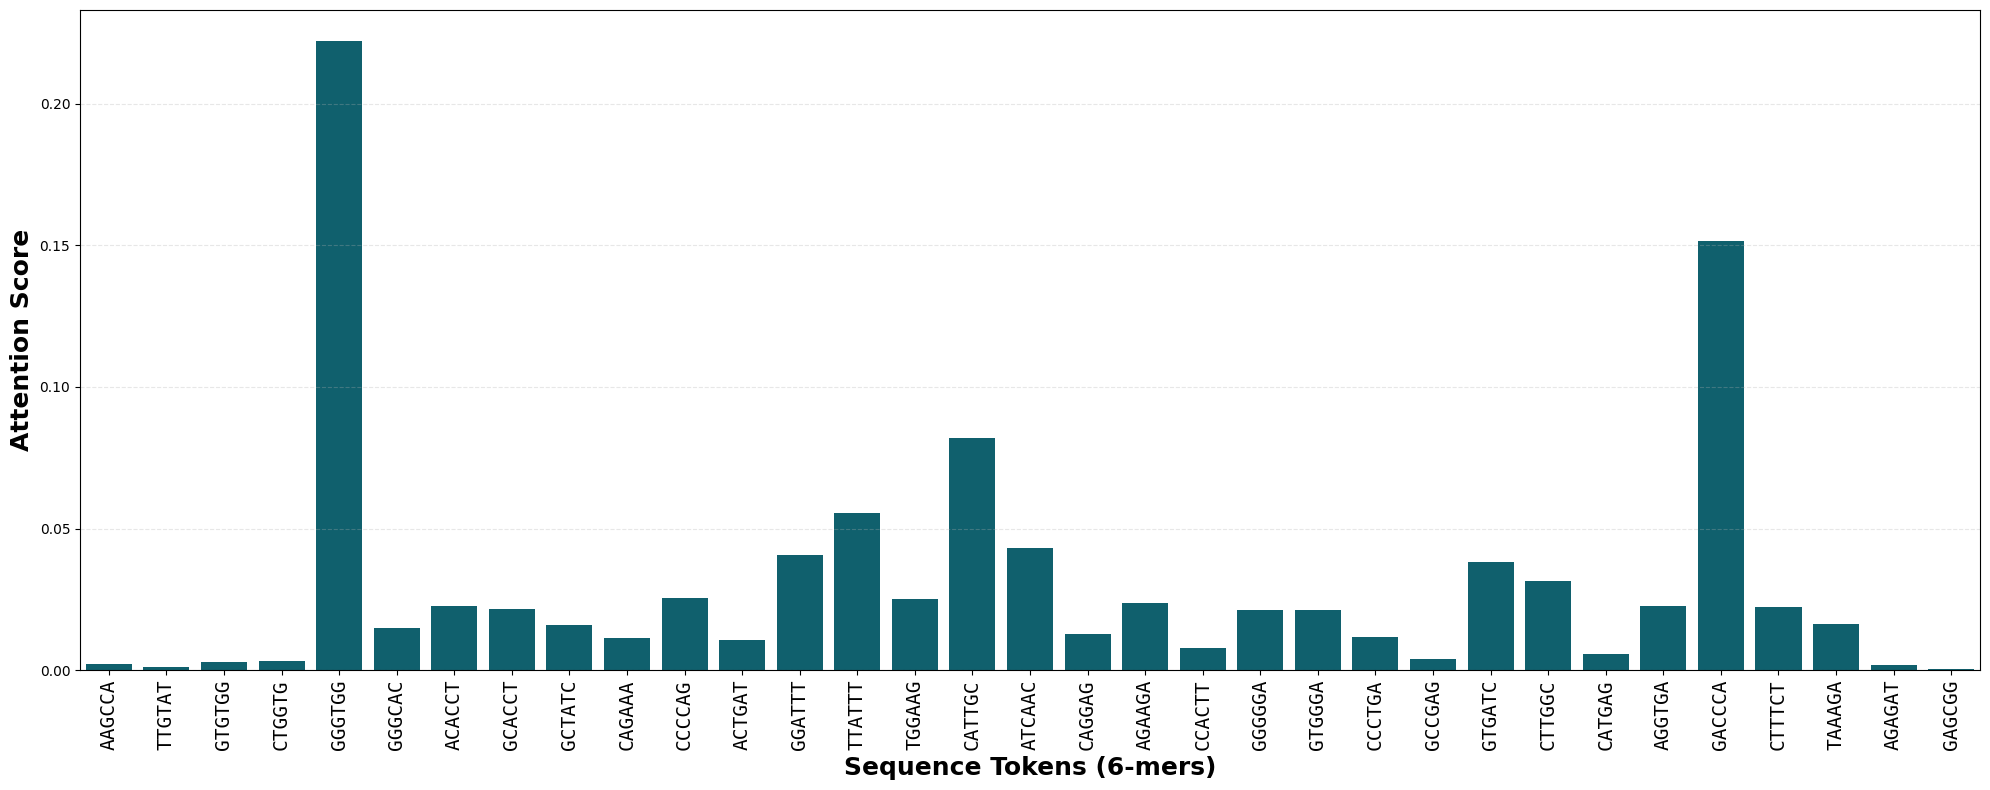

In [13]:


def plot_attention_only(sample_idx, dataset, matrices, k=6, highlight_pos=None):
    """
    Plotta l'Attenzione per un dato campione usando matrici Numpy o Tensor.
    """
    
    # --- A. RECUPERO DATI ---
    sample = dataset[sample_idx]
    
    # Gestione robusta della sequenza (se nel dataset è bytes o stringa)
    seq = sample['sequence']
    # label = sample['label'] # Opzionale, se disponibile
    
    # --- MODIFICA 1: Recupero Matrice (Supporta sia Tensor che Numpy) ---
    attn_data = matrices[sample_idx]
    
    # Se è un Tensore PyTorch, convertilo in Numpy. Se è già Numpy, lascialo così.
    if hasattr(attn_data, 'numpy'):
        attn_data = attn_data.numpy()
        
    # --- MODIFICA 2: Slicing (Logica: Skip CLS [0] e skip ultimi [-3:]) ---
    # Usa .ndim per Numpy invece di .dim()
    if attn_data.ndim > 1:
        # Caso (1, Seq_Len) -> Prendi la prima riga
        attn_values = attn_data[0, 1:-3]
    else:
        # Caso (Seq_Len,) -> Prendi diretto
        attn_values = attn_data[1:-3] 
    
    # --- Tokenizzazione (Logica originale mantenuta) ---
    tokens = [seq[i:i+k] for i in range(0, k * len(attn_values), k)]
    
    # Safety Check: Tronchiamo al minimo comune
    min_len = min(len(tokens), len(attn_values))
    tokens = tokens[:min_len]
    attn_values = attn_values[:min_len]
    
    # Creazione DataFrame
    df_plot = pd.DataFrame({
        'Index': range(len(tokens)),
        'Token': tokens,
        'Attention': attn_values
    })

    # --- B. PLOTTING ---
    plt.figure(figsize=(20, 8))
    
    # Colori
    colors = ['#006B7D'] * len(tokens) # Teal base
    
    # Highlight opzionale
    if highlight_pos is not None:
        target_idx = highlight_pos - 1
        # if 0 <= target_idx < len(tokens):
        #     colors[target_idx] = '#D4880F' 

    ax = sns.barplot(data=df_plot, x='Token', y='Attention', palette=colors)
    
    # Stile
    ax.set_ylabel('Attention Score', fontsize=18, fontweight='bold')
    ax.set_xlabel('Sequence Tokens (6-mers)', fontsize=18, fontweight='bold')
    # ax.set_title(f"Sample #{sample_idx} | Attention Profile", fontsize=16, fontweight='bold')
    
    plt.xticks(rotation=90, ha='center', fontfamily='monospace', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================================
# ESEMPIO DI UTILIZZO CON I DATI DI INFERENZA
# ==========================================================

# 1. Appiattisci la lista di matrici (Step Fondamentale!)
# L'output dell'inferenza è una lista di BATCH (es. [Batch1(32, 144), Batch2(32, 144)...])
# Dobbiamo farla diventare una lista di CAMPIONI (es. [Campione1, Campione2, ...])
flat_importance = []
if 'importance' in results: # 'results' è l'output di predict_only
    for batch_matrix in results['importance']:
        # batch_matrix ha shape (Batch_Size, Seq_Len) o (Batch, 1, Seq_Len)
        for sample_matrix in batch_matrix:
            flat_importance.append(sample_matrix)

# 2. Usa la funzione modificata
# Ora 'flat_importance' ha lunghezza uguale a len(dataset_to_study)
idx_to_plot = 1 # Scegli l'indice che vuoi
    
plot_attention_only(
    sample_idx=idx_to_plot, 
    dataset=dataset_to_study, # Il dataset usato per creare il dataloader 'test'
    matrices=flat_importance, # La lista appiattita
    highlight_pos=17
)